W niniejszym ćwiczeniu zostanie użyty algorytm śledzenia z rodziny filtrów korelacyjnych. W algorytmach tych wykorzystywany jest pewien filtr za pomocą którego zamodelowany jest śledzony obiekt. W celu predykcji nowego położenia obiektu, dokonywana jest korelacja obszaru śledzenia z filtrem. Obliczenia wykonywane są w dziedzinie częstotliwości, ponieważ szybciej jest obliczyć transformatę Fouriera za pomocą algorytmu FFT (*Fast Fourier Transform*) i skorzystać z twierdzenia o konwolucji, niż obliczać korelację wprost. Algorytmy śledzenia z rodziny filtrów korelacyjnych cechuje niska złożoność obliczeniowa (czyli możliwe jest śledzenie w czasie rzeczywistym) przy zachowaniu konkurencyjnej jakości śledzenia.

W dzisiejszym ćwiczeniu wykorzystana zostanie najprostsza wersja algorytmu opisana w publikacji:
https://www.cs.colostate.edu/~draper/papers/bolme_cvpr10.pdf

W pierwszej klatce obrazu filtr jest inicjalizowany na podstawie fragmentu obrazu w skali szarości $f$, który zawiera obiekt do śledzenia.

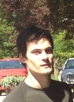

$H^*_t = \frac{A}{B}$

$A = \sum^N_i G_i \odot F^*_i$        (1a)

$B = \sum^N_i F_i \odot F^*_i$        (1b)

gdzie $F_i$ jest dyskretną transformatą Fouriera fragmentu obrazu $f_i$, natomiast $G$ jest transformatą Fouriera dwuwymiarowego rozkładu Gaussa $g$ o rozmiarze śledzonego obszaru: 

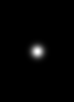

Działanie $\odot$ oznacza mnożenie typu element przez element, a $X^*$ oznacza sprzężenie zespolone (wynikiem transformacji Fouriera są liczby zespolone).

Suma po $i$ oznacza, że z jednej próbki obiektu w pierwszej klatce śledzenia należy utworzyć zbiór $N$ próbek uczących składających się z losowych rotacji próbki bazowej:

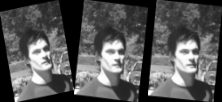

Następnie, w każdej klatce obrazu dokonywana jest predykcja położenia:

$\mathcal{F^{-1}}\{ F \odot H^* \}$      (2)

gdzie $\mathcal{F^{-1}}$ oznacza odwrotną, dyskretną transformację Fouriera, natomiast $F$ jest tutaj transformatą fragmentu obrazu scentrowanego na ostatnio znanej pozycji obiektu. Otrzymana w ten sposób mapa korelacji reprezentuje przewidziane prez filtr przesunięcie obiektu względem poprzedniej klatki obrazu:

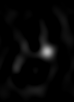

Po każdej predykcji, filtr jest aktualizowany fragmentem aktualnej klatki obrazu wyciętym na nowej pozycji obiektu:

$A_t = \eta G \odot F^*_t + (1-\eta) A_{t-1}$       (3a)

$B_t = \eta F_t \odot F^*_t + (1-\eta) B_{t-1}$     (3b)

Gdzie $\eta \in [0, 1]$ jest przyjętym współczynnikiem uczenia.

Na początek zaimportujmy potrzebne biblioteki i zadeklarujmy parametry algorytmu:

In [1]:
# from google.colab import drive
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow
import imutils
import os
from os.path import join
from matplotlib import pyplot as plt

# drive.mount('/content/gdrive')
DATASET_DIR = 'sequences'

SIGMA = 17
SEARCH_REGION_SCALE = 2.0
LR = 0.125
NUM_PRETRAIN = 128
VISUALIZE = True

Ćwiczenie przeprowadzone będzie z użyciem sekwencji ze zbioru VOT2013

Pomocnicze funkcje do czytania pliku zawierającego pozycje obiektu i wizualizacji zbioru:

In [2]:
def load_gt(gt_file):

    with open(gt_file, 'r') as file:
        lines = file.readlines()

    lines = [line.split(',') for line in lines]
    lines = [[int(float(coord)) for coord in line] for line in lines]
    # returns in x1y1wh format
    return lines


def show_sequence(sequence_dir):

    imgdir = join(sequence_dir, 'color')
    imgnames = os.listdir(imgdir)                  
    imgnames.sort()
    gt_boxes = load_gt(join(sequence_dir, 'groundtruth.txt'))

    for imgname, gt in zip(imgnames, gt_boxes):
        img = cv2.imread(join(imgdir, imgname))
        position = [int(x) for x in gt]
        cv2.rectangle(img, (position[0], position[1]), (position[0]+position[2], position[1]+position[3]), (255, 0, 0), 2)
        cv2.imshow('demo', img)
        if cv2.waitKey(0) == ord('q'):
            break
        # cv2_imshow(img)


In [3]:

# show_sequence(join(DATASET_DIR, 'jump'))

Na początek warto zaimplementować funkcję, która przyjmując klatkę obrazu oraz pozycję obiektu, zwróci fragment obrazu w skali szarości zawierający śledzony obiekt. Przyjmijmy, że położenie obiektu przekazywane jest w formacie $[x_1, y_1, w, h]$ ($x_1$, $y_1$) - lewy-górny punkt prostokąta otaczającego; $w$, $h$ - szerokość i wysokość).

Do śledzenia szybkich obiektów przydatnym jest uwzględniać nieco większy obszar scentrowany na pozycji obiektu, `SEARCH_REGION_SCALE` razy szerszy i wyższy niż sam obiekt.

🔔 **TODO (1)** zmodyfikować wartości `xmin, xmax, ymin, ymax` tak, aby obejmowały szerszy kontekst obrazu - wykorzystać zadeklarowany parametr `SEARCH_REGION_SCALE`.

🔔 **TODO (2)** Zabezpieczyć algorytm przed wykraczaniem obszaru poszukiwań poza kadr poprzez zastosowanie paddingu wejściowej klatki obrazu (przydatna funkcja: `frame = cv2.copyMakeBorder(frame, y_pad, y_pad, x_pad, x_pad, cv2.BORDER_REFLECT)` - padding przyjąć przynajmniej o rozmiarze obszaru poszukiwania). Należy pamiętać o tym, że współrzędne punktów na oryginalnym obrazie powinny zostać odpowiednio skorygowane o padding.

Warto przetestować zaimplementowaną funkcję poprzez wyświetlenie uzyskanego obszaru.

In [4]:
def crop_search_window(bbox, frame):

    xmin, ymin, width, height = bbox
    cx = xmin + width / 2
    cy = ymin + height / 2
    sw = width * SEARCH_REGION_SCALE
    sh = height * SEARCH_REGION_SCALE

    x_pad = int(np.ceil(sw))
    y_pad = int(np.ceil(sh))
    frame = cv2.copyMakeBorder(frame, y_pad, y_pad, x_pad, x_pad, cv2.BORDER_REFLECT)

    x1 = int(cx - sw / 2) + x_pad
    y1 = int(cy - sh / 2) + y_pad
    x2 = int(cx + sw / 2) + x_pad
    y2 = int(cy + sh / 2) + y_pad

    return cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY)


Przydatna będzie funkcja generująca dwuwymiarowy rozkład Gaussa - kluczowe jest, aby ta funkcja oraz powyższa zwracały macierz o takich samych rozmiarach dla danego obiektu.

In [5]:
def get_gauss_response(gt_box, size=None):

    if size is None:
        height = int(round(gt_box[3] * SEARCH_REGION_SCALE))
        width = int(round(gt_box[2] * SEARCH_REGION_SCALE))
    else:
        height, width = size

    cy, cx = height // 2, width // 2
    yy, xx = np.mgrid[:height, :width]
    dist = (np.square(xx - cx) + np.square(yy - cy)) / (2 * SIGMA)
    return np.exp(-dist)


Przed obliczeniem transformaty Fouriera, fragment obrazu należy odpowiednio przygotować.

🔔 **TODO (3)**
Proszę uzupełnić funkcję, która dokona preprocessingu wejściowego fragmentu obrazu w skali szarości:
- transformacja funkcją logarytm (warto dodać 1 do każdego piksela, aby uniknąć logarytmowania zera) - funkcja `np.log()`
- normalizacja (odjęcie wartości średniej i podzielenie przez odchylenie standardowe) - funkcje `np.mean()`, `np.std()`

Przemnożenie przez dwuwymiarowe okno Hanninga zostało zaimplementowane korzystając z funkcji `np.hanning()` generującą dyskretne, jednowymiarowe okno o zadanej szerokości. 

In [6]:
def pre_process(img):

    img = img.astype(np.float32)
    img = np.log(img + 1)
    img = (img - np.mean(img)) / (np.std(img) + 1e-5)

    window = np.outer(np.hanning(img.shape[0]), np.hanning(img.shape[1]))
    return img * window


Do inicjalizacji należy wygenerować losowe próbki uczące. Do tego posłuży funkcja `random_warp`.

🔔 **TODO (4)** Proszę zaimplementować funkcję, która dokona losowej rotacji wejściowego fragmentu obrazu.
- wygenerować losowy kąt w zakrecie -+15 stopni (wykorzystać `np.random.uniform()` )
- obrócić obrazek o wylosowany kąt (funkcja `img_rot = imutils.rotate_bound(img, angle)` )
- przeskalować obrócony obrazek do oryginalnych rozmiarów wejściowego obrazka (funkcja `cv2.resize()` )

Funkcję również warto przetestować wizualnie przy użyciu funkcji `cv2.imshow()`. W przypadku problemów/wątpliwości zadanie można wykonać na koniec, algorytm powinien do pewnego stopnia zadziałać dla inicjalizacji tylko jedną próbką bazową.

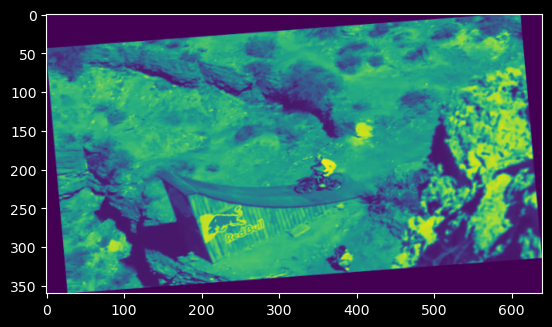

In [7]:
def random_warp(img):

    h, w = img.shape[:2]
    rotated = imutils.rotate_bound(img, np.random.uniform(-15, 15))
    return cv2.resize(rotated, (w, h))

img = cv2.imread('sequences/jump/color/00000001.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
warped_img = random_warp(img)
plt.imshow(warped_img.astype(np.uint8))


Poniżej przedstawiono implementację inicjalizacji na podstawie pierwszej klatki obrazu i pierwszej pozycji obiektu. Przed realizacją równań $(1a, 1b)$
, funkcja `pre_training()` wydobywa fragment obrazu, dokonuje preprocessingu i oblicza transformatę $F_i$ za pomocą zaimplementowanych wcześniej funkcji.
Wykorzystywana jest funkcja `np.fft.fft2()` realizująca algorytm FFT oraz `np.conjugate()` obliczająca sprzężenie zespolone.

Jeżeli funkcja `random_warp()` nie jest zaimplementowana, pierwsze eksperymenty należy przeprowadzić dla `NUM_PRETRAIN = 0`.


In [8]:
def initialize(init_frame, init_gt):

    template = crop_search_window(init_gt, init_frame)
    g = get_gauss_response(init_gt, size=template.shape)
    G = np.fft.fft2(g)
    Ai, Bi = pre_training(init_gt, init_frame, G, template=template)

    return Ai, Bi, G


def pre_training(init_gt, init_frame, G, template=None):

    if template is None:
        template = crop_search_window(init_gt, init_frame)
    fi = pre_process(template)
    
    Ai = G * np.conjugate(np.fft.fft2(fi))                # (1a)
    Bi = np.fft.fft2(fi) * np.conjugate(np.fft.fft2(fi))  # (1b)

    for _ in range(NUM_PRETRAIN):
        fi = pre_process(random_warp(template))

        Ai = Ai + G * np.conjugate(np.fft.fft2(fi))               # (1a)
        Bi = Bi + np.fft.fft2(fi) * np.conjugate(np.fft.fft2(fi)) # (1b)

    return Ai, Bi

Niżej zaimplementowana funkcja `track()` przedstawia wysokopoziomowo jedną iterację działania algorytmu śledzenia. Przyjmuje ona aktualne parametry filtru oraz aktualną pozycję obiektu (w drugiej klatce śledzenia będą to parametry uzyskanie z inicjalizacji oraz pozycja startowa obiektu) i zwraca obliczoną pozycję oraz zaktualizowany filtr.

In [9]:
def track(image, position, Ai, Bi, G):

    response = predict(image, position, Ai/Bi)
    new_position = update_position(response, position)
    newAi, newBi = update(image, new_position, Ai, Bi, G)

    return new_position, newAi, newBi

🔔 **TODO (5)** W oparciu o schemat działania funkcji `track()`, proszę zaimplementować brakujące funkcje:
- `predict()` realizującą równanie $(2)$, czyli odpowiedź filtru,
- `update()` realizującą równania $(3a, 3b)$,

Analogicznie do funkcji `pre_training()`, należy na sam początek wykorzystać funkcję `crop_search_window()` do wycięcia odpowiedniego fragmentu obrazu oraz funkcję `pre_process()` do wstępnej obróbki tego fragmentu.

Do wyznaczenia odwrotnej transformaty Fouriera w funkcji `predict()` proszę wykorzystać funkcję `np.fft.ifft2()`. Funkcja `predict()` powinna zwracać macierz rzeczywistą, dlatego proszę użyć funkcji `np.real()` przed zwróceniem ostatecznej wartości.

W funkcji `update()` proszę wykorzystać parametr `LR` będący współczynnikiem uczenia przy aktualizacji filtru.

🔔 **TODO (6)** Pozostało jeszcze zaimplementować funkcję `update_position()`, która przyjmując odpowiedź filtru, zwróci nową pozycję obiektu.

- należy wyznaczyć współrzędne elementu o największej wartości (podpowiedź: funkcja `np.max(response)` zwraca maksymalną wartość macierzy `response`, a funkcja `np.where(response == max_val)` zwraca indeks macierzy `response`, który ma wartość `max_val`)
- może się zdarzyć, że więcej niż jeden indeks będzie miał wartość maksymalną - aby się przed tym zabezpieczyć można uwzględniać tylko pierwszy indeks zwrócony przez `np.where()` lub jeszcze lepiej - obliczyć średni indeks (`np.mean()`),
- przesunięcie maksymalnej wartości od środka odpowiedzi filtru jest przewidzianym przesunięciem położenia obiektu - należy zmodyfikować pierwszą i drugą współrzędną położenia (zmiany w szerokości i wysokości obiektu ignorujemy w tym ćwiczeniu).

In [10]:
def predict(frame, position, H):

    fi = pre_process(crop_search_window(position, frame))
    return np.real(np.fft.ifft2(H * np.fft.fft2(fi)))


def update(frame, position, Ai, Bi, G):

    Fi = np.fft.fft2(pre_process(crop_search_window(position, frame)))
    Ai = LR * G * np.conjugate(Fi) + (1 - LR) * Ai
    Bi = LR * Fi * np.conjugate(Fi) + (1 - LR) * Bi
    return Ai, Bi


def update_position(spatial_response, position):

    peak = np.unravel_index(np.argmax(spatial_response), spatial_response.shape)
    dy = peak[0] - spatial_response.shape[0] / 2.0
    dx = peak[1] - spatial_response.shape[1] / 2.0

    new_position = position.copy()
    new_position[0] += dx
    new_position[1] += dy
    return new_position


Zaimplementowany system proszę przetestować poprzez prostą metrykę będącą średnim IoU w każdej klatce śledzenia

(dać te gotowe funkcje lub kazać samemu to zrobić)
(w folderze są sekwencje jump - prostsza, sunshade - trudniejsza)

In [11]:
def bbox_iou(box1, box2):

    b1_x1, b1_y1 = box1[0], box1[1]
    b1_x2, b1_y2 = box1[0] + box1[2], box1[1] + box1[3]
    b2_x1, b2_y1 = box2[0], box2[1]
    b2_x2, b2_y2 = box2[0] + box2[2], box2[1] + box2[3]

    inter_w = max(0, min(b1_x2, b2_x2) - max(b1_x1, b2_x1))
    inter_h = max(0, min(b1_y2, b2_y2) - max(b1_y1, b2_y1))
    inter_area = inter_w * inter_h

    union_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1) + (b2_x2 - b2_x1) * (b2_y2 - b2_y1) - inter_area
    return inter_area / (union_area + 1e-16)


def test_sequence(dataset_dir, sequence):

    seqdir = join(dataset_dir, sequence)
    imgdir = join(seqdir, 'color')
    imgnames = sorted(os.listdir(imgdir))

    print('init frame:', join(imgdir, imgnames[0]))
    init_img = cv2.imread(join(imgdir, imgnames[0]))
    gt_boxes = load_gt(join(seqdir, 'groundtruth.txt'))
    position = gt_boxes[0]
    Ai, Bi, G = initialize(init_img, position)

    if VISUALIZE:
        x, y, w, h = position
        cv2.rectangle(init_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.imshow('demo', init_img)
        cv2.waitKey(0)

    results = []
    for imgname in imgnames[1:]:
        img = cv2.imread(join(imgdir, imgname))
        position, Ai, Bi = track(img, position, Ai, Bi, G)
        results.append(position.copy())

        if VISUALIZE:
            x, y, w, h = [round(v) for v in position]
            cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.imshow('demo', img)
            if cv2.waitKey(0) == ord('q'):
                break

    cv2.destroyAllWindows()
    return results, gt_boxes


In [ ]:

DATASET_DIR = 'sequences'
# sequences = os.listdir(DATASET_DIR)
sequences = ['jump', 'sunshade']
ious_per_sequence = {}
for sequence in sequences:

    results, gt_boxes = test_sequence(DATASET_DIR, sequence)
    ious = []
    for res_box, gt_box in zip(results, gt_boxes[1:]):
        iou = bbox_iou(res_box, gt_box)
        ious.append(iou)

    ious_per_sequence[sequence] = np.mean(ious)
    print(sequence, ':', np.mean(ious))

print('Mean IoU:', np.mean(list(ious_per_sequence.values())))

init frame: sequences/sunshade/color/00000001.jpg


2026-05-17 18:52:40.602 python[38008:6243524] +[IMKClient subclass]: chose IMKClient_Legacy
2026-05-17 18:52:40.602 python[38008:6243524] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


ValueError: operands could not be broadcast together with shapes (102,74) (102,73) 

: 